In [93]:
#!pip install sentence-transformers

What subset of transformers models would be best to try?

How about a set of experiments with different number length too. So dataset1 includes numbers 0-10, dataset2 0-100, and so on.
Then, let's compare performance between number vs spell-out.
- I think it also had trouble with floats?


I'm thinking... in the pipeline of experiments... apart from different transformers, maybe distances to the embeddings can be tested? Like the method for each, like L2 and other distances ETC.

BERT-base-uncased collapses to 0 for everything except 30, which it guesses correctly.
BERT-base-cased collapses to 52 for everything.

# Cleaned notebook

In [94]:
import pathlib
from dataset_writing import *
from experiment import run_experiment
from plots import *
from models import SentenceEncoder
import pandas as pd

In [95]:
MODELS = {
    "MiniLM-L6": "all-MiniLM-L6-v2",
    "mpnet": "all-mpnet-base-v2",
    "BERT-nli-mean-tokens": "bert-base-nli-mean-tokens",
    "BERT-base-uncased": "bert-base-uncased",
    "BERT-base-cased": "bert-base-cased",
    "RoBERTa": "all-roberta-large-v1",
    "MiniLM-L12": "all-MiniLM-12-v2",
    "e5-small": "intfloat/e5-small",
    "unsup-simcse-bert": "princeton-nlp/unsup-simcse-bert-base-uncased",
    "MathBERT": "tbs17/mathbert",
    "LLM2VEC": "McGill-NLP/LLM2Vec-Meta-Llama-3-8B-Instruct-mntp-supervised",
    "BERT-nli-cls-token": "bert-base-nli-cls-token",
    "nli-mean-numeric-triplet": "nli-mean-numeric-triplet",
    "bert-plain-triplet": "bert-plain-triplet"
}

In [96]:
model_name = MODELS["bert-plain-triplet"]
#DATASET_FILE = pathlib.Path("../data/ages.txt")
AGE_RANGE = range(0, 100)
PCA_DIMS = 30
TSNE_PERPLEXITY = 30 # check the method to define the best perplexity.

In [97]:
encoder = SentenceEncoder(model_name)

In [98]:
age_format = "float"
DATASET_FILE = pathlib.Path(f"../data/ages_{age_format}.txt")
#DATASET_FILE = pathlib.Path(f"../data/cleaned_data.csv")
out_dir = pathlib.Path(f"../results/{age_format}/{model_name}")
#out_dir = pathlib.Path(f"../results/bigger_dataset/{model_name}")
out_dir.mkdir(parents=True, exist_ok=True)

In [99]:
#generate_sentences(DATASET_FILE, style=age_format) # already generated.

In [100]:
#sentences = load_sentences(path=DATASET_FILE)
sentences = load_bigger_dataset(path=DATASET_FILE)

Number of sentences: 99
['My age is 14.00', 'My age is 3.00', 'My age is 94.00', 'My age is 35.00', 'My age is 31.00', 'My age is 28.00', 'My age is 17.00', 'My age is 94.00', 'My age is 13.00', 'My age is 86.00']


In [101]:
results = run_experiment(encoder, sentences, ages = AGE_RANGE)

In [102]:
df_points = pd.DataFrame({
    "age": list(AGE_RANGE),
    "true": results["true"],
    "pred": results["pred"],
    "error": results["errors"],
    "within_+-2": results["correct"],
    "full_error": results["full_error"],
})

safe_name = model_name.replace("/", "-")
csv_path = out_dir / f"{safe_name}_results.csv"
df_points.to_csv(csv_path, index=False)
print("Saved results to {}".format(csv_path))

Saved results to ..\results\float\bert-plain-triplet\bert-plain-triplet_results.csv


In [103]:
summary = pd.DataFrame([{
    "model": model_name,
    "accuracy": results["accuracy"],
    "exact_match_acc": results["exact_match_acc"]
}])

summary_path = out_dir / f"{safe_name}_summary.csv"
summary.to_csv(summary_path, index=False)

print("Summary saved to {}".format(summary_path))

Summary saved to ..\results\float\bert-plain-triplet\bert-plain-triplet_summary.csv


In [104]:
print(results["exact_match_acc"])

0.83


In [105]:
print(results["accuracy"])

0.91


In [106]:
# If you want to re-do the graphs without having to re-run the experiments.

"""df_points  = pd.read_csv(csv_path)

results = {
    "true":       df_points["true"].tolist(),
    "pred":       df_points["pred"].tolist(),
    "errors":     df_points["error"].tolist(),
    "correct":    df_points["within_+-2"].tolist(),
    "full_error": df_points["full_error"].tolist(),
    "exact_match_acc": df_points["exact_match_acc"].tolist()
}"""

'df_points  = pd.read_csv(csv_path)\n\nresults = {\n    "true":       df_points["true"].tolist(),\n    "pred":       df_points["pred"].tolist(),\n    "errors":     df_points["error"].tolist(),\n    "correct":    df_points["within_+-2"].tolist(),\n    "full_error": df_points["full_error"].tolist(),\n    "exact_match_acc": df_points["exact_match_acc"].tolist()\n}'

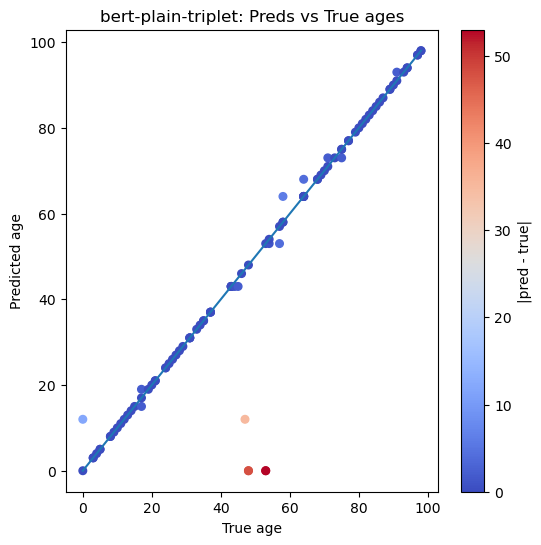

In [107]:
plot_concentration(safe_name, out_dir, results['true'], results['pred'], results['errors'])

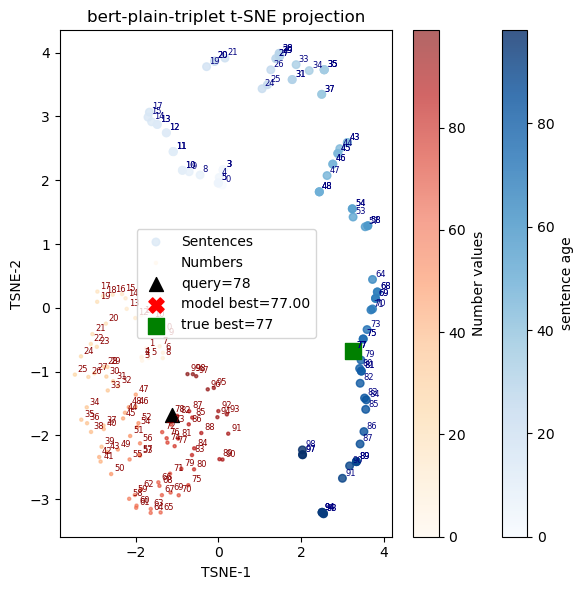

In [108]:
plot_tsne(safe_name, out_dir,
          78,
          sentences=sentences,
          encoder=encoder,
          pca_dims=PCA_DIMS,
          perp=90,
          show_labels=True
          )

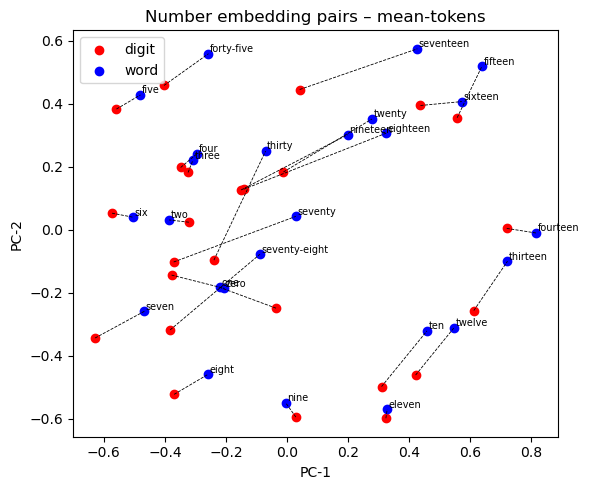

In [109]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

enc = SentenceTransformer("bert-base-nli-mean-tokens")

numbers   = list(range(21)) + [30, 45, 70, 78]                       # 0-20 like the paper
digits    = [str(n) for n in numbers]
words     = ["zero","one","two","three","four","five","six","seven","eight",
             "nine","ten","eleven","twelve","thirteen","fourteen","fifteen",
             "sixteen","seventeen","eighteen","nineteen","twenty", "thirty", "forty-five", "seventy", "seventy-eight"]

emb_d = enc.encode(digits, normalize_embeddings=False)
emb_w = enc.encode(words , normalize_embeddings=False)

# centre & length-normalise (paper trick)
all_emb = np.vstack([emb_d, emb_w])
mu      = all_emb.mean(0, keepdims=True)
emb_d   = normalize(emb_d - mu)
emb_w   = normalize(emb_w - mu)

xy = PCA(n_components=2, random_state=0).fit_transform(np.vstack([emb_d, emb_w]))
xy_d, xy_w = xy[:len(numbers)], xy[len(numbers):]

plt.figure(figsize=(6,5))
plt.scatter(xy_d[:,0], xy_d[:,1], color="red" , label="digit")
plt.scatter(xy_w[:,0], xy_w[:,1], color="blue", label="word")

# draw dashed arrows “digit → word”
for (xd,yd),(xw,yw) in zip(xy_d, xy_w):
    plt.plot([xd,xw],[yd,yw],"k--",linewidth=0.6)

for i,(xw,yw) in enumerate(xy_w):
    plt.text(xw+0.005, yw+0.005, words[i], fontsize=7)

plt.xlabel("PC-1"); plt.ylabel("PC-2")
plt.title("Number embedding pairs – mean-tokens")
plt.legend(); plt.tight_layout(); plt.show()


No sentence-transformers model found with name bert-base-uncased. Creating a new one with mean pooling.


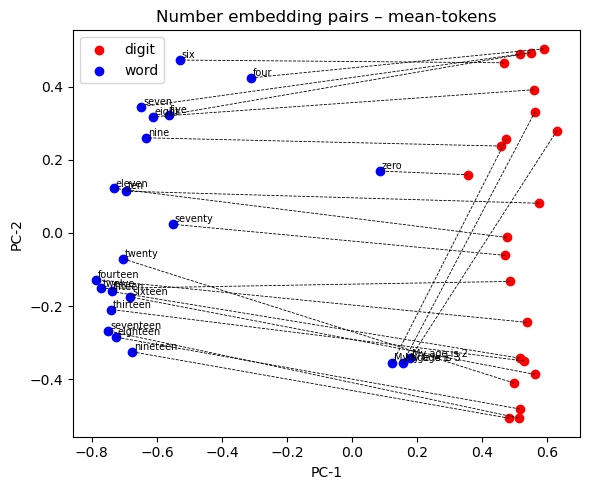

In [110]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

enc = SentenceTransformer("bert-base-uncased")

numbers   = list(range(21)) + [70]                       # 0-20 like the paper
digits    = [str(n) for n in numbers]
"""words     = ["zero","one","two","three","four","five","six","seven","eight",
             "nine","ten","eleven","twelve","thirteen","fourteen","fifteen",
             "sixteen","seventeen","eighteen","nineteen","twenty", "seventy"]"""
words     = ["zero","My age is 1","My age is 2","My age is 3","four","five","six","seven","eight",
             "nine","ten","eleven","twelve","thirteen","fourteen","fifteen",
             "sixteen","seventeen","eighteen","nineteen","twenty", "seventy"]

emb_d = enc.encode(digits, normalize_embeddings=False)
emb_w = enc.encode(words , normalize_embeddings=False)

# centre & length-normalise (paper trick)
all_emb = np.vstack([emb_d, emb_w])
mu      = all_emb.mean(0, keepdims=True)
emb_d   = normalize(emb_d - mu)
emb_w   = normalize(emb_w - mu)

xy = PCA(n_components=2, random_state=0).fit_transform(np.vstack([emb_d, emb_w]))
xy_d, xy_w = xy[:len(numbers)], xy[len(numbers):]

plt.figure(figsize=(6,5))
plt.scatter(xy_d[:,0], xy_d[:,1], color="red" , label="digit")
plt.scatter(xy_w[:,0], xy_w[:,1], color="blue", label="word")

# draw dashed arrows “digit → word”
for (xd,yd),(xw,yw) in zip(xy_d, xy_w):
    plt.plot([xd,xw],[yd,yw],"k--",linewidth=0.6)

for i,(xw,yw) in enumerate(xy_w):
    plt.text(xw+0.005, yw+0.005, words[i], fontsize=7)

plt.xlabel("PC-1"); plt.ylabel("PC-2")
plt.title("Number embedding pairs – mean-tokens")
plt.legend(); plt.tight_layout(); plt.show()


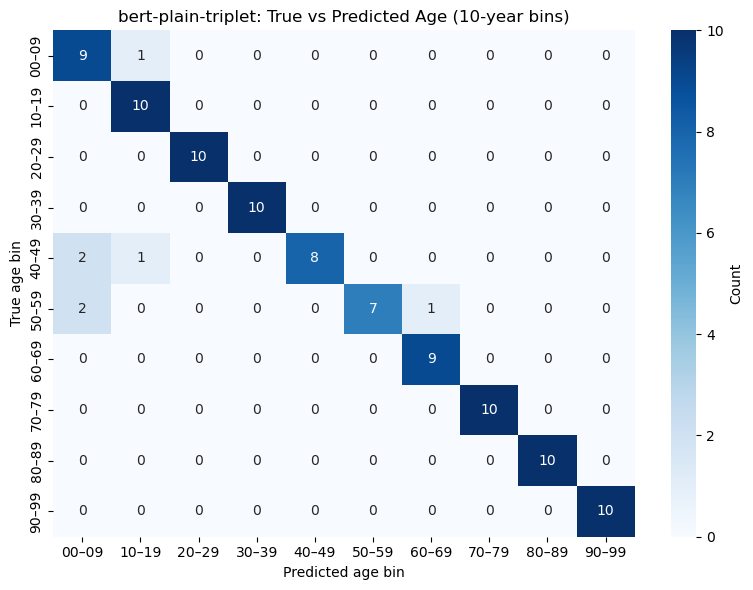

In [111]:
heatmap(results, safe_name, out_dir)

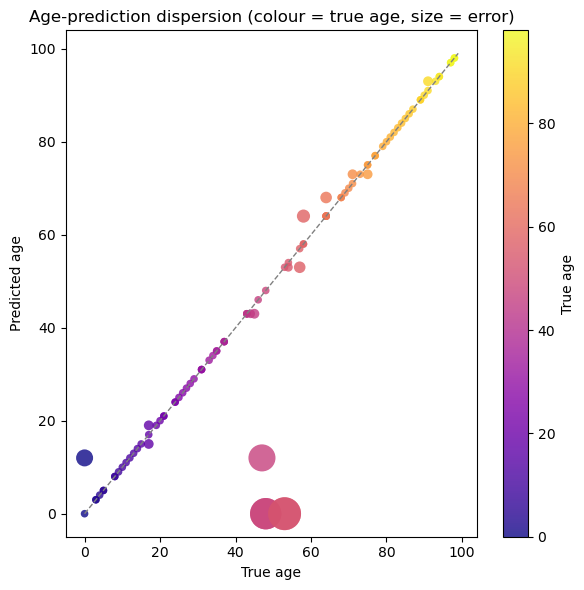

In [112]:
plot_concentration_color_gradient(results, safe_name, out_dir)

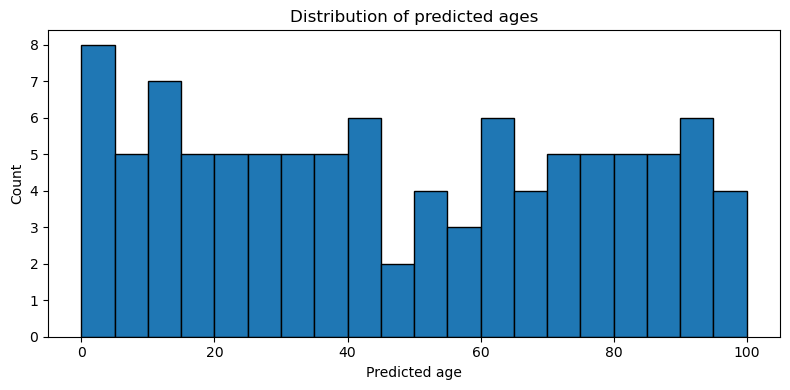

In [113]:
plot_prediction_histogram(results["pred"], bins=range(0,101,5), model_name=safe_name, out_folder=out_dir)

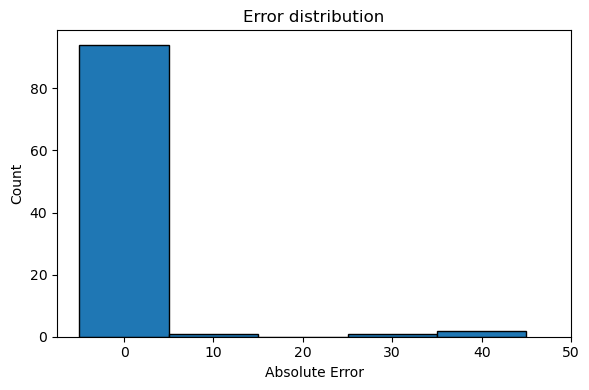

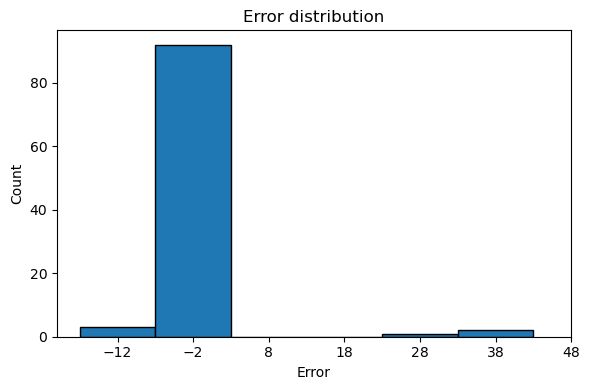

In [114]:
plot_error_histogram(results["errors"], safe_name, out_dir, absolute=True)
plot_error_histogram(results["full_error"], safe_name, out_dir, absolute=False)

Histogram is a great way to visualize error, but adding another one on top that is error instead of absolute error, to see if it tends to collapse upwards or downwards, maybe?

In [115]:
"""def results_summary(DATASETS, accuracy="accuracy"):

    #DATASETS = {"digits", "float", "scientific", "words"}
    #DATASETS = {"bigger_dataset"}
    root = Path("../results")

    VALID_MODELS = {
        "all-MiniLM-L6-v2",
        "all-mpnet-base-v2",
        "bert-base-nli-mean-tokens",
        "bert-base-uncased",
        "bert-base-cased",
        "all-roberta-large-v1",
        "all-MiniLM-12-v2",
        "intfloat/e5-small",
        "princeton-nlp/unsup-simcse-bert-base-uncased",
        "mathbert-base-uncased",
    }
    values = {"accuracy", "exact_match_acc"}

    records = []

    for f in root.rglob("*_summary.csv"):
        # find the first parent folder that matches a known dataset
        dataset_folder = next((p for p in f.parents if p.name in DATASETS), None)
        if dataset_folder is None:
            continue

        dataset = dataset_folder.name
        # everything *below* the dataset folder is the (possibly nested) model path
        model_tag = f.parent.relative_to(dataset_folder).as_posix()  # keeps slashes

        if VALID_MODELS and model_tag not in VALID_MODELS:
            continue # ignore models outside the list

        acc = pd.read_csv(f).loc[0, "accuracy"]
        exact_match_acc = pd.read_csv(f).loc[0, "exact_match_acc"]
        records.append({"model": model_tag, "dataset": dataset, "accuracy": acc, "Exact match": exact_match_acc})

    overall = (pd.DataFrame(records)
               .pivot_table(index="model",
                            values=["accuracy", "Exact match"],
                            aggfunc="first")
               .sort_index())

    print(overall.to_markdown(floatfmt=".3f"))
    overall.to_csv(root / "overall_summary.csv")"""

'def results_summary(DATASETS, accuracy="accuracy"):\n\n    #DATASETS = {"digits", "float", "scientific", "words"}\n    #DATASETS = {"bigger_dataset"}\n    root = Path("../results")\n\n    VALID_MODELS = {\n        "all-MiniLM-L6-v2",\n        "all-mpnet-base-v2",\n        "bert-base-nli-mean-tokens",\n        "bert-base-uncased",\n        "bert-base-cased",\n        "all-roberta-large-v1",\n        "all-MiniLM-12-v2",\n        "intfloat/e5-small",\n        "princeton-nlp/unsup-simcse-bert-base-uncased",\n        "mathbert-base-uncased",\n    }\n    values = {"accuracy", "exact_match_acc"}\n\n    records = []\n\n    for f in root.rglob("*_summary.csv"):\n        # find the first parent folder that matches a known dataset\n        dataset_folder = next((p for p in f.parents if p.name in DATASETS), None)\n        if dataset_folder is None:\n            continue\n\n        dataset = dataset_folder.name\n        # everything *below* the dataset folder is the (possibly nested) model path\n 

In [116]:
VALID_MODELS = {
        "all-MiniLM-L6-v2",
        "all-mpnet-base-v2",
        "bert-base-nli-mean-tokens",
        "bert-base-uncased",
        "bert-base-cased",
        "all-roberta-large-v1",
        "all-MiniLM-12-v2",
        "intfloat/e5-small",
        "princeton-nlp/unsup-simcse-bert-base-uncased",
        "tbs17/mathbert",
        "bert-base-nli-cls-token",
    "nli-mean-numeric-triplet",
    "bert-plain-triplet"
    }
DATASETS = {"digits", "float", "words"}
#DATASETS = {"bigger_dataset"}
results_summary(DATASETS, VALID_MODELS, accuracy="accuracy")

| model                                        |   digits |   float |   words |
|:---------------------------------------------|---------:|--------:|--------:|
| all-MiniLM-L6-v2                             |    0.850 |   0.790 |   0.420 |
| all-mpnet-base-v2                            |    0.110 |   0.300 |   0.170 |
| all-roberta-large-v1                         |    0.180 |   0.360 |   0.230 |
| bert-base-cased                              |    0.110 |   0.470 |   0.050 |
| bert-base-nli-cls-token                      |    0.940 | nan     | nan     |
| bert-base-nli-mean-tokens                    |    0.950 |   0.930 |   0.430 |
| bert-base-uncased                            |    0.050 |   0.490 |   0.020 |
| bert-plain-triplet                           |    0.930 |   0.910 | nan     |
| intfloat/e5-small                            |    0.830 |   0.770 |   0.390 |
| nli-mean-numeric-triplet                     |    0.940 |   0.930 | nan     |
| princeton-nlp/unsup-simcse-bert-base-u